In [ ]:
# inporting library
import pandas as pd

df = pd.read_csv("student_social_media.csv")

In [ ]:
# Fill missing numeric values
df = df.fillna(df.select_dtypes(include=['number']).mean())

# Remove duplicates
df = df.drop_duplicates()

# Outlier removal
numeric_cols = ["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night",
                "Mental_Health_Score", "Conflicts_Over_Social_Media"]

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df_clean = df[~outlier_mask].copy()

In [ ]:
df_clean["Addiction_Level"] = df_clean["Addicted_Score"].apply(
    lambda x: "High" if x >= 7 else "Low"
)

In [ ]:
df_clean

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Addiction_Level
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,High
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,Low
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,High
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,Low
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5,Low
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9,High
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7,High
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4,Low


In [ ]:
df_clean["Addiction_Level"].value_counts()

Addiction_Level
High    406
Low     296
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Features and target
X = df_clean[["Avg_Daily_Usage_Hours",
              "Sleep_Hours_Per_Night",
              "Mental_Health_Score",
              "Conflicts_Over_Social_Media"]]

y = df_clean["Addiction_Level"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results_clf = {}

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results_clf[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label="High"),
        "Recall": recall_score(y_test, y_pred, pos_label="High"),
        "F1-score": f1_score(y_test, y_pred, pos_label="High")
    }


In [ ]:
results_clf

{'Logistic Regression': {'Accuracy': 0.9929078014184397,
  'Precision': 0.9879518072289156,
  'Recall': 1.0,
  'F1-score': 0.9939393939393939},
 'KNN': {'Accuracy': 0.9858156028368794,
  'Precision': 0.9878048780487805,
  'Recall': 0.9878048780487805,
  'F1-score': 0.9878048780487805},
 'SVM': {'Accuracy': 0.9929078014184397,
  'Precision': 0.9879518072289156,
  'Recall': 1.0,
  'F1-score': 0.9939393939393939},
 'Decision Tree': {'Accuracy': 0.9787234042553191,
  'Precision': 0.9876543209876543,
  'Recall': 0.975609756097561,
  'F1-score': 0.9815950920245399},
 'Random Forest': {'Accuracy': 0.9858156028368794,
  'Precision': 0.9878048780487805,
  'Recall': 0.9878048780487805,
  'F1-score': 0.9878048780487805}}

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select features for clustering
X = df_clean[["Avg_Daily_Usage_Hours",
              "Sleep_Hours_Per_Night",
              "Mental_Health_Score",
              "Conflicts_Over_Social_Media"]]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[ 0.23134301, -0.33683712, -0.20595769,  0.15722915],
       [-2.27213116,  0.5591828 ,  1.61268754, -2.99633838],
       [ 0.87740086, -1.680867  , -1.1152803 ,  1.20841833],
       ...,
       [ 0.55437193, -0.15763313, -0.20595769,  0.15722915],
       [-0.49547207,  0.5591828 ,  1.61268754, -0.89396003],
       [ 1.03891532, -0.5160411 , -1.1152803 ,  1.20841833]])

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


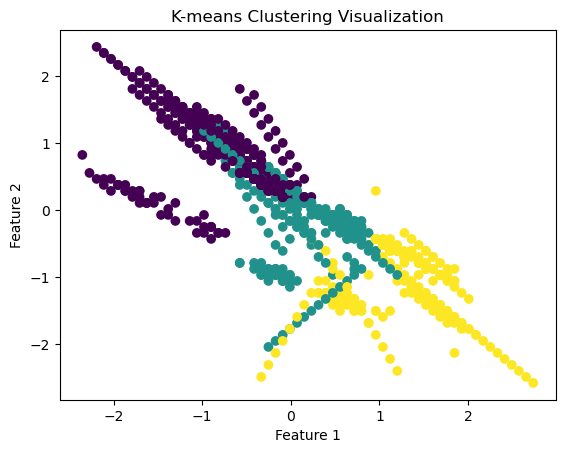

In [ ]:
# Apply K-means with k = 3
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df_clean["Cluster"], cmap="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-means Clustering Visualization")
plt.show()